<a href="https://colab.research.google.com/github/alexkjohnson/fastai2019/blob/main/02_fully_connected.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [28]:
!git clone https://github.com/alexkjohnson/fastai2019.git

Cloning into 'fastai2019'...
remote: Enumerating objects: 3, done.
remote: Counting objects: 100% (3/3), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 3 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (3/3), 19.91 KiB | 19.91 MiB/s, done.


In [29]:
import os
os.chdir('fastai2019')

In [30]:
!pwd

/content/fastai2019/fastai2019


---

In [31]:
import os
import urllib.request
from pathlib import Path

In [32]:
from pathlib import Path
from IPython.core.debugger import set_trace
# from fastai import datasets
import pickle, gzip, math, torch, matplotlib as mpl
import matplotlib.pyplot as plt
from torch import tensor

In [33]:
MNIST_URL = 'https://github.com/mnielsen/neural-networks-and-deep-learning/raw/master/data/mnist.pkl.gz'

# Set path to the local Colab content folder
path = Path('mnist.pkl.gz')

if not path.exists():
    print("Downloading MNIST pkl.gz...")
    urllib.request.urlretrieve(MNIST_URL, path)

print(f"File downloaded to: {path.absolute()}")

File downloaded to: /content/fastai2019/fastai2019/mnist.pkl.gz


In [34]:
def get_data(path):
    # path = datasets.download_data(MNIST_URL, ext='.gz')
    with gzip.open(path, 'rb') as f:
        ((x_train, y_train), (x_valid, y_valid), _) = pickle.load(f, encoding='latin-1')
    return map(tensor, (x_train,y_train,x_valid,y_valid))

def normalize(x, m, s): return (x-m)/s

broadcasting used in `normalize` function;
- tensor (`x`)
- subtracts the mean (`m`)
- standard dev (`s`)

In [35]:
x_train,y_train,x_valid,y_valid = get_data(path)

In [36]:
train_mean,train_std = x_train.mean(),x_train.std()
train_mean,train_std

(tensor(0.1304), tensor(0.3073))

notice they're not `0` & `1` - but we want them to be
- therefore; we subtract the mean & divide by std dev
  - not for the validation set; we don't subtract the validation sets mean & divide by validation sets std dev.
  - Because if we did those 2 datasets would be on totally different scales
    - eg: if training set was mainly green frogs & valid set was mainly red frogs, if we normalized with the validation sets mean & variance we would end up with them both having the same avg colouration and we wouldn't be able to tell the two apart
  - **important:** when normalizing, **always** make sure the validation and training set are normalized in the same way

In [37]:
x_train = normalize(x_train, train_mean, train_std)
# NB: Use training, not validation mean for validation set
x_valid = normalize(x_valid, train_mean, train_std)

In [38]:
train_mean,train_std = x_train.mean(),x_train.std()
train_mean,train_std

(tensor(3.8966e-08), tensor(1.))

after doing so we can see the mean & std dev are very close to 0 & 1

In [48]:
# export
def test_near_zero(a,tol=1e-3): assert a.abs() < tol

In [49]:
test_near_zero(x_train.mean())
test_near_zero(1-x_train.std())

define n,m and c - the size of our training set & the number of activations we're eventually going to need in our model respectively

In [42]:
n,m = x_train.shape
c = y_train.max()+1
n,m,c

(50000, 784, tensor(10))

## Foundations version
### Basic architecture

the model is going to have 1 hidden layer, and normally we would want the final output to have 10 activations because we would use cross-entropy against those 10 activations, but for now to simplify things we're going to use MSE instead which means we're going to have 1 activation
- makes no sense from a modelling point of view (will fix later)

In [43]:
# num hidden
nh = 50

our 2 layers; we're going to need 2 weight matrices & 2 bias vectors:

In [45]:
# standard xavier init
w1 = torch.randn(m,nh)/math.sqrt(m)
b1 = torch.zeros(nh)
w2 = torch.randn(nh,1)/math.sqrt(nh)
b2 = torch.zeros(1)

Our inputs to the first layer are now mean 0, std 1.  
We want the inputs to the 2nd layer to also be mean 0, std 1

in general, normal random number of mean 0 and std dev of 1/sqrt((eg:m/nh)), will give you an output of 0,1

In [50]:
test_near_zero(w1.mean())
test_near_zero(w1.std()-1/math.sqrt(m))

In [51]:
# This should be ~ (0,1) (mean,std)...
x_valid.mean(),x_valid.std()

(tensor(-0.0059), tensor(0.9924))

In [52]:
def lin(x, w, b): return x@w + b

In [53]:
t = lin(x_valid, w1, b1)

In [54]:
#...so should this, because we used xavier init, which is designed to do this
t.mean(),t.std()

(tensor(0.0798), tensor(1.0077))

In [55]:
def relu(x): return x.clamp_min(0.)

In [56]:
t = relu(lin(x_valid, w1, b1))

In [57]:
#...actually it really should be this!
t.mean(),t.std()

(tensor(0.4348), tensor(0.6245))

Unfortunately that does not have mean 0, stddev 1. Why not?
- we had data that was mean 0, stddev 1 -> then we removed anything that was smaller than 0 -> obviously doesn't have a mean 0 and has about half the stddev it originally had
- if your variance halves each layer, by the end of a deep network it's drastically reduced / all gone -> your gradient have totally disappeared

From pytorch docs: a: the negative slope of the rectifier used after this layer (0 for ReLU by default)

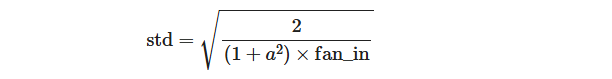

This was introduced in the paper that described the Imagenet-winning approach from He et al: Delving Deep into Rectifiers, which was also the first paper that claimed "super-human performance" on Imagenet (and, most importantly, it introduced resnets!)

In [67]:
# kaiming init / he init for relu
w1 = torch.randn(m,nh)*math.sqrt(2/m)

In [68]:
w1.mean(),w1.std()

(tensor(-6.7848e-05), tensor(0.0504))

In [69]:
t = relu(lin(x_valid, w1, b1))
t.mean(),t.std()

(tensor(0.5187), tensor(0.7941))

gives us a relatively good variance
- the mean is still not very good because as previously seen everything below 0 is deleted so our mean is now half instead of 0

In [70]:
#export
from torch.nn import init

In [71]:
w1 = torch.zeros(m,nh)
init.kaiming_normal_(w1, mode='fan_out')
t = relu(lin(x_valid, w1, b1))

In [73]:
# init.kaiming_normal_??

In [74]:
w1.mean(),w1.std()

(tensor(8.4801e-05), tensor(0.0505))

In [75]:
t.mean(),t.std()

(tensor(0.5734), tensor(0.8491))

In [76]:
w1.shape

torch.Size([784, 50])

In [77]:
import torch.nn

In [78]:
torch.nn.Linear(m,nh).weight.shape

torch.Size([50, 784])

In [80]:
# torch.nn.Linear.forward??

In [81]:
# torch.nn.functional.linear??

Note: in PyTorch `F` always refers to the `torch.nn.functional` module

In PyTorch a linear layers doesn't just do a matrix product, it does a matrix product with a transpose

that's why previously we had to pass in the "opposite" info `mode='fan_out'` when doing it with our linear layer with doesn't have a transpose

In [90]:
# torch.nn.Conv2d??

In [92]:
# torch.nn.modules.conv._ConvNd.reset_parameters??

In [93]:
# what if...?
def relu(x): return x.clamp_min(0.) - 0.5

In [95]:
# kaiming init / he init for relu
w1 = torch.randn(m,nh)*math.sqrt(2./m )
t1 = relu(lin(x_valid, w1, b1))
t1.mean(),t1.std()

(tensor(0.1438), tensor(0.9218))

Now we have; ReLU, Linear, init -> therefore we can do a forward pass.

Remember: in PyTorch a model can just be a fn.  
Here it is:

In [98]:
def model(xb):
    l1 = lin(xb, w1, b1)
    l2 = relu(l1)
    l3 = lin(l2, w2, b2)
    return l3

In [99]:
%timeit -n 10 _=model(x_valid)

27.5 ms ± 2.68 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [100]:
assert model(x_valid).shape==torch.Size([x_valid.shape[0],1])

assert to make sure the shape seems sensible.

The next thing we need for our forward pass is a loss function.
- remember for now we're simplifying things by using MSE even though that's obviously a dumb idea

## Loss function: MSE

In [101]:
model(x_valid).shape

torch.Size([10000, 1])

our model returns something of size [10000,1], but MSE would expect a single vector of size 10000

We need `squeeze()` to get rid of that trailing `(,1)`, in order to use `mse`. (Of course, mse is not a suitable loss function for multi-class classification; we'll use a better loss function soon. We'll use mse for now to keep things simple.)

In [102]:
#export
def mse(output, targ): return (output.squeeze(-1) - targ).pow(2).mean()

- note: `.squeeze()` gets rid of all unit axes - commonly leads to issues. eg: when you have a batch size of 1,1 - that 1,1 will get squeezed down to a scalar so things break.
- rather than just calling `.squeeze()` it's better to say which dim you want to squeeze -> more resiliant to edge case of batch size of 1

for MSE have to make sure these are floats:

In [103]:
y_train,y_valid = y_train.float(),y_valid.float()

In [104]:
preds = model(x_train)

In [105]:
preds.shape

torch.Size([50000, 1])

In [106]:
mse(preds, y_train)

tensor(34.3902)

we've now done a forward pass

what we need is a backward pass - because that's what tells us how to update our parameters.

so we need gradients:

## Gradients and backward pass

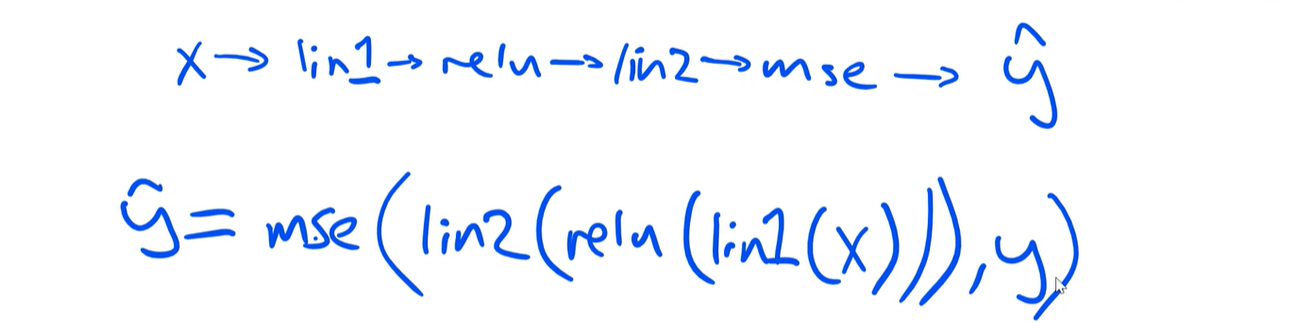

we want the gradient wrt the parameters

to do the chain rule, we're going to have to start with the last fn.  
the last fn on the outside was the loss fn (mse)

In [107]:
def mse_grad(inp, targ):
    # grad of loss with respect to output of previous layer
    inp.g = 2. * (inp.squeeze() - targ).unsqueeze(-1) / inp.shape[0]

for the chain rule, we're going to have to multiply all these together.  
so if we store it in the `.g` attribute of the prev layer, can then refer to it:

In [108]:
def relu_grad(inp, out):
    # grad of relu with respect to input activations
    inp.g = (inp>0).float() * out.g

In [109]:
def lin_grad(inp, out, w, b):
    # grad of matmul with respect to input
    inp.g = out.g @ w.t()
    w.g = (inp.unsqueeze(-1) * out.g.unsqueeze(1)).sum(0)
    b.g = out.g.sum(0)

note: the gradient of a matrix product is simply the matrix product with the transpose

In [111]:
def forward_and_backward(inp, targ):
    # forward pass:
    l1 = inp @ w1 + b1
    l2 = relu(l1)
    out = l2 @ w2 + b2
    # we don't actually need the loss in backward!
    loss = mse(out, targ)

    # backward pass:
    mse_grad(out, targ)
    lin_grad(l2, out, w2, b2)
    relu_grad(l1, l2)
    lin_grad(inp, l1, w1, b1)

in the backward pass it calls each of the gradients backwards/in reverse order because we need that for the chain rule

notice: every time we're passing in the result of the forward pass, and it also has access to the gradient of the next layer

backprop is the chain rule where we just save away all the intermediate calculations so we don't have to calculate them again

this is now a full forward & backward pass

note: the `loss` value is never actually used because the `loss` value never appears in the gradients.
- still probably want it to be able to print out, etc

In [112]:
forward_and_backward(x_train, y_train)

In [113]:
# Save for testing against later
w1g = w1.g.clone()
w2g = w2.g.clone()
b1g = b1.g.clone()
b2g = b2.g.clone()
ig  = x_train.g.clone()

these now contain all of our gradients which we're going to use for the optimizer



We cheat a little bit and use PyTorch autograd to check our results.

In [114]:
xt2 = x_train.clone().requires_grad_(True)
w12 = w1.clone().requires_grad_(True)
w22 = w2.clone().requires_grad_(True)
b12 = b1.clone().requires_grad_(True)
b22 = b2.clone().requires_grad_(True)

clone all of our weights and bias' and input, then turn on `requires_grad_` for all of them

`requires_grad_` is how you take a PyTorch tensor & turn it into an autogradified PyTorch tensor
- it’s still the same "type" of object (a torch.Tensor), but you are flipping a switch that tells PyTorch: "Start keeping a diary of every mathematical operation performed on this specific tensor."
- When you set `requires_grad=True` (either during creation or via the in-place `requires_grad_()` method), PyTorch attaches a Computational Graph to that tensor.
  - Normal Tensor: Just a chunk of memory with numbers. If you do c = a + b, PyTorch calculates c and forgets how it got there.
  - Autogradified Tensor: PyTorch stores the Gradient Function (grad_fn). If you do c = a + b, c now "remembers" it was created by an Addition operation.

1. Weights ($W$) and Biases ($b$): These ALWAYS need requires_grad_(True). They are the parameters we want to update.
2. Input Data ($x$): Usually DOES NOT need grad. We don't want to change the pixels of the digit 7; we want to change the weights that look at those pixels.
3. Activations: These get a grad_fn automatically because they are calculated using weights that have grads.

In [115]:
def forward(inp, targ):
    # forward pass:
    l1 = inp @ w12 + b12
    l2 = relu(l1)
    out = l2 @ w22 + b22
    # we don't actually need the loss in backward!
    return mse(out, targ)

In [116]:
loss = forward(xt2, y_train)

In [117]:
loss.backward()

In [125]:
def test(a,b,cmp,cname=None):
    if cname is None: cname=cmp.__name__
    assert cmp(a,b),f"{cname}:\n{a}\n{b}"

def test_eq(a,b): test(a,b,operator.eq,'==')

In [126]:
def near(a,b): return torch.allclose(a, b, rtol=1e-3, atol=1e-5)
def test_near(a,b): test(a,b,near)

In [127]:
test_near(w22.grad, w2g)
test_near(b22.grad, b2g)
test_near(w12.grad, w1g)
test_near(b12.grad, b1g)
test_near(xt2.grad, ig )

pytorch stores things in `.grad`

that's a NN that contains all the pieces we need written from scratch

we will now refactor it to something that's somewhat similar to the pytorch api

## Refactor model
### Layers as classes

lets take each of our layers (ReLU & linear) and create classes.  
for the forward -> use `__call__`

**Remember:** `__call__` means it can now treated as if it's a fn
- so if you call this class with parentheses `()` it calls this `__call__` fn.

we save the input & output, then return the output

backward is the same as we had before, but here we save it in `self.inp.g`

In [128]:
class Relu():
    def __call__(self, inp):
        self.inp = inp
        self.out = inp.clamp_min(0.)-0.5
        return self.out

    def backward(self): self.inp.g = (self.inp>0).float() * self.out.g

In [129]:
class Lin():
    def __init__(self, w, b): self.w,self.b = w,b

    def __call__(self, inp):
        self.inp = inp
        self.out = inp@self.w + self.b
        return self.out

    def backward(self):
        self.inp.g = self.out.g @ self.w.t()
        # Creating a giant outer product, just to sum it, is inefficient!
        self.w.g = (self.inp.unsqueeze(-1) * self.out.g.unsqueeze(1)).sum(0)
        self.b.g = self.out.g.sum(0)

    def lin_grad(inp, out, w, b):
        # grad of matmul with respect to input
        inp.g = out.g @ w.t()
        w.g = (inp.unsqueeze(-1) * out.g.unsqueeze(1)).sum(0)
        b.g = out.g.sum(0)

  notice, for linear we don't just want the grad of the outputs wrt the inputs, we also need the gradients of the outputs wrt the weights and the output wrt the bias -> why we have 3 lots of `.g` / gradients stored here

In [130]:
class Mse():
    def __call__(self, inp, targ):
        self.inp = inp
        self.targ = targ
        self.out = (inp.squeeze() - targ).pow(2).mean()
        return self.out

    def backward(self):
        self.inp.g = 2. * (self.inp.squeeze() - self.targ).unsqueeze(-1) / self.targ.shape[0]

with this refactoring we can now create our model using a `Model` class.

notice: no pytorch is used here, it's all from scratch

In [131]:
class Model():
    def __init__(self, w1, b1, w2, b2):
        self.layers = [Lin(w1,b1), Relu(), Lin(w2,b2)]
        self.loss = Mse()

    def __call__(self, x, targ):
        for l in self.layers: x = l(x)
        return self.loss(x, targ)

    def backward(self):
        self.loss.backward()
        for l in reversed(self.layers): l.backward()

In [132]:
w1.g,b1.g,w2.g,b2.g = [None]*4
model = Model(w1, b1, w2, b2)

In [133]:
%time loss = model(x_train, y_train)

CPU times: user 116 ms, sys: 886 µs, total: 117 ms
Wall time: 119 ms


In [134]:
%time model.backward()

CPU times: user 2.88 s, sys: 4.74 s, total: 7.63 s
Wall time: 8.37 s


In [135]:
test_near(w2g, w2.g)
test_near(b2g, b2.g)
test_near(w1g, w1.g)
test_near(b1g, b1.g)
test_near(ig, x_train.g)

correct, but took a long time (will come back to that)

we have a lot of duplicate code. To get rid of this we can create a new class called `Module` which

## Module.forward()

In [136]:
class Module():
    def __call__(self, *args):
        self.args = args
        self.out = self.forward(*args)
        return self.out

    def forward(self): raise Exception('not implemented')
    def backward(self): self.bwd(self.out, *self.args)

now we're not going to use `__call__` to implement our forward, but instead have it call something called `self.forward`

In [137]:
class Relu(Module):
    def forward(self, inp): return inp.clamp_min(0.)-0.5
    def bwd(self, out, inp): inp.g = (inp>0).float() * out.g

In [138]:
class Lin(Module):
    def __init__(self, w, b): self.w,self.b = w,b

    def forward(self, inp): return inp@self.w + self.b

    def bwd(self, out, inp):
        inp.g = out.g @ self.w.t()
        self.w.g = torch.einsum("bi,bj->ij", inp, out.g)
        self.b.g = out.g.sum(0)

In [139]:
class Mse(Module):
    def forward (self, inp, targ): return (inp.squeeze() - targ).pow(2).mean()
    def bwd(self, out, inp, targ): inp.g = 2*(inp.squeeze()-targ).unsqueeze(-1) / targ.shape[0]

In [140]:
class Model():
    def __init__(self):
        self.layers = [Lin(w1,b1), Relu(), Lin(w2,b2)]
        self.loss = Mse()

    def __call__(self, x, targ):
        for l in self.layers: x = l(x)
        return self.loss(x, targ)

    def backward(self):
        self.loss.backward()
        for l in reversed(self.layers): l.backward()

In [141]:
w1.g,b1.g,w2.g,b2.g = [None]*4
model = Model()

In [142]:
%time loss = model(x_train, y_train)

CPU times: user 121 ms, sys: 1.71 ms, total: 123 ms
Wall time: 124 ms


In [143]:
%time model.backward()

CPU times: user 231 ms, sys: 145 ms, total: 376 ms
Wall time: 566 ms


In [144]:
test_near(w2g, w2.g)
test_near(b2g, b2.g)
test_near(w1g, w1.g)
test_near(b1g, b1.g)
test_near(ig, x_train.g)

Can see that looks almost like pytorch / can see:
- why it's done this way
- why we have to inherit from `nn.Module`
- why we have to define `forward`

This is why; it lets PyTorch factor out all this duplicate stuff so all we have to do is do the implementation.

### Without einsum

In [145]:
class Lin(Module):
    def __init__(self, w, b): self.w,self.b = w,b

    def forward(self, inp): return inp@self.w + self.b

    def bwd(self, out, inp):
        inp.g = out.g @ self.w.t()
        self.w.g = inp.t() @ out.g
        self.b.g = out.g.sum(0)

In [146]:
w1.g,b1.g,w2.g,b2.g = [None]*4
model = Model()

In [147]:
%time loss = model(x_train, y_train)

CPU times: user 138 ms, sys: 0 ns, total: 138 ms
Wall time: 168 ms


In [148]:
%time model.backward()

CPU times: user 250 ms, sys: 65.2 ms, total: 316 ms
Wall time: 412 ms


In [149]:
test_near(w2g, w2.g)
test_near(b2g, b2.g)
test_near(w1g, w1.g)
test_near(b1g, b1.g)
test_near(ig, x_train.g)

## nn.Linear and nn.Module

In [150]:
from torch import nn

In [151]:
class Model(nn.Module):
    def __init__(self, n_in, nh, n_out):
        super().__init__()
        self.layers = [nn.Linear(n_in,nh), nn.ReLU(), nn.Linear(nh,n_out)]
        self.loss = mse

    def __call__(self, x, targ):
        for l in self.layers: x = l(x)
        return self.loss(x.squeeze(), targ)

In [152]:
model = Model(m, nh, 1)

In [153]:
%time loss = model(x_train, y_train)

CPU times: user 136 ms, sys: 754 µs, total: 137 ms
Wall time: 160 ms


In [154]:
%time loss.backward()

CPU times: user 101 ms, sys: 1.6 ms, total: 102 ms
Wall time: 125 ms


at this point, we're ready in the next lesson to now build a training loop.

We have a multi-layer FC NN (rectified network), matmul, forward & backward passes, it's nicely refactored out into classes and a Module class

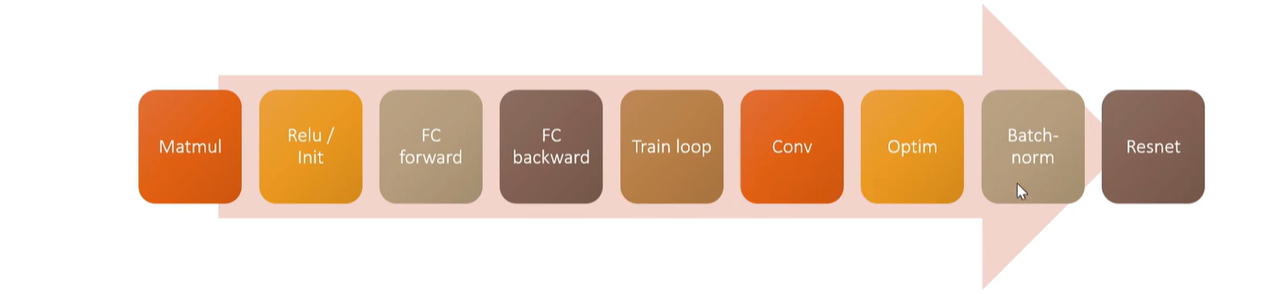